In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:

df_donors = pd.read_csv('Donors_dataset.csv')

df_donors


,TARGET_B,TARGET_D,CONTROL_NUMBER,MONTHS_SINCE_ORIGIN,DONOR_AGE,IN_HOUSE,URBANICITY,SES,CLUSTER_CODE,HOME_OWNER,...,LIFETIME_GIFT_RANGE,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LAST_GIFT_AMT,CARD_PROM_12,NUMBER_PROM_12,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_FIRST_GIFT,FILE_AVG_GIFT,FILE_CARD_GIFT
0,0,NaN,5,101,87.0,0,?,?,.,H,...,15.0,20.0,5.0,15.0,5,12,26,92,8.49,7
1,1,10.0,12,137,79.0,0,R,2,45,H,...,20.0,25.0,5.0,17.0,7,21,7,122,14.72,12
2,0,NaN,37,113,75.0,0,S,1,11,H,...,23.0,28.0,5.0,19.0,11,32,6,105,16.75,16
3,0,NaN,38,92,NaN,0,U,2,4,H,...,14.0,17.0,3.0,15.0,11,33,6,92,11.76,12
4,0,NaN,41,101,74.0,0,R,2,49,U,...,20.0,25.0,5.0,25.0,6,19,18,92,8.83,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19367,0,NaN,191687,89,66.0,1,U,1,3,H,...,22.0,25.0,3.0,15.0,6,13,18,81,17.17,3
19368,0,NaN,191710,137,77.0,1,C,1,24,H,...,9.0,10.0,1.0,10.0,6,13,21,130,7.81,13
19369,0,NaN,191746,29,NaN,1,S,1,11,U,...,0.0,15.0,15.0,15.0,3,9,23,23,15.00,0
19370,0,NaN,191775,129,78.0,1,?,?,.,U,...,20.0,25.0,5.0,25.0,7,24,8,129,18.33,11


In [14]:
### Logistic regression, only with numerical features.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Use only the numeric predictors
X_B_num = df_B[num_features]
y_B_num = df_B['TARGET_B']

# Train/test split - 25% test / 75% train. Check the right values for this.
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_num, y_B_num, random_state=42
) # random state is just to memorize this particular set of random split.

# Fit logistic regression
model_LR = LogisticRegression(solver='liblinear').fit(X_B_train, y_B_train) # there are

print("Train set score (Accuracy) =", model_LR.score(X_B_train, y_B_train))
print("Test set score (Accuracy)  =", model_LR.score(X_B_test, y_B_test))



Train set score (Accuracy) = 0.7492601004886779
Test set score (Accuracy)  = 0.7522196985339665


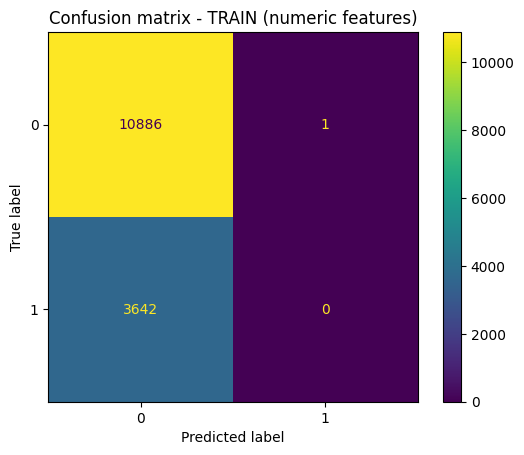

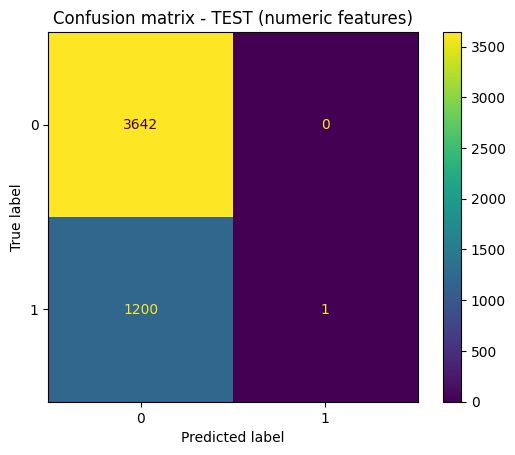

In [15]:
### Checking the matrices, because the accuracy value is deceiving.
### Since there are more negative examples than positive ones, the model is just assuming that almost all the values are negative.
### You can see this in the matrices.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Predictions on train and test sets
y_B_train_pred = model_LR.predict(X_B_train)
y_B_test_pred = model_LR.predict(X_B_test)


# Train confusion matrix
cm_train = confusion_matrix(y_B_train, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=model_LR.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (numeric features)")
plt.show()

# Test confusion matrix
cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=model_LR.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (numeric features)")
plt.show()






In [6]:
# Probability of being donor for every row in df_B
P_donor_all = model_LR.predict_proba(df_B[num_features])[:, 1]

# Add it as a new column
df_B['P_donor'] = P_donor_all

df_B[['TARGET_B', 'P_donor']].head()

,TARGET_B,P_donor
0,0,0.234552
1,1,0.261192
2,0,0.247253
3,0,0.263394
4,0,0.242523


Train set score (Accuracy) = 0.7493289283501962
Test set score (Accuracy)  = 0.7522196985339665



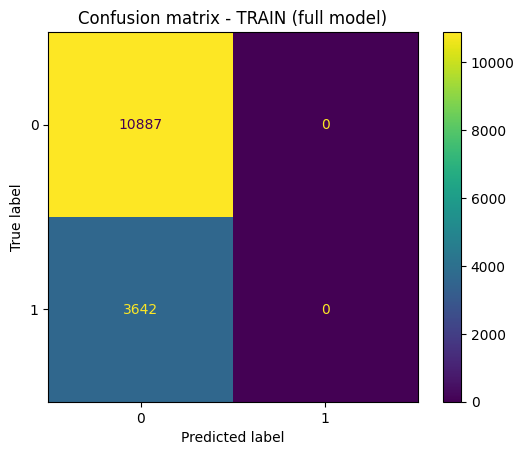

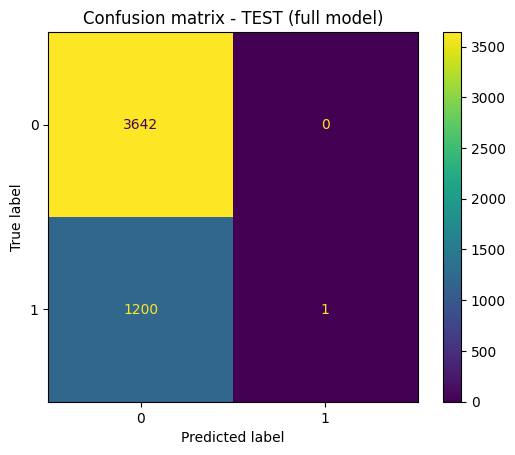

In [7]:
### Logistic Regression. Including categorical features.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(solver='liblinear', max_iter=1000)
logreg_full.fit(X_B_train, y_B_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_full.score(X_B_train, y_B_train))
print("Test set score (Accuracy)  =", logreg_full.score(X_B_test, y_B_test))

print()


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()



Balanced TRAIN accuracy = 0.5550521691378364
Original TEST accuracy  = 0.5104274210200289



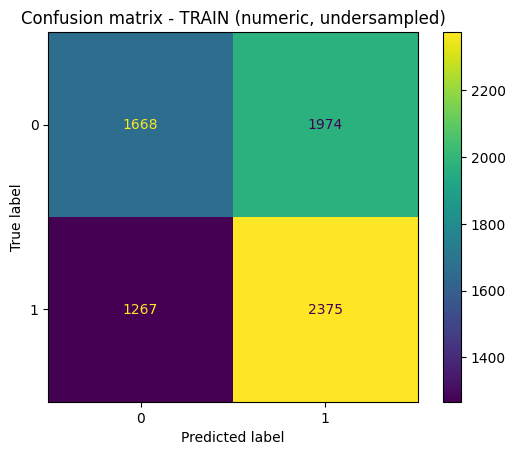

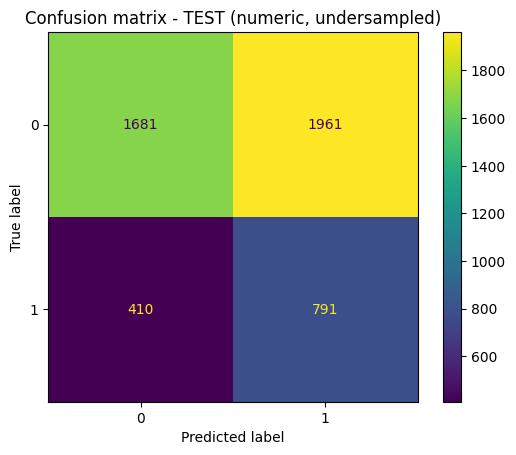

In [9]:
### Logistic Regression with only the numerical features, but now with balanced data trough downsampling the non donors.

from sklearn.utils import resample

X_B_num = df_B[num_features]
y_B_num = df_B['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_num, y_B_num, random_state=42
)

train_df = pd.concat([X_B_train, y_B_train], axis=1)

train_non_donors = train_df[train_df['TARGET_B'] == 0]
train_donors = train_df[train_df['TARGET_B'] == 1]

# Undersampling non-donors.
train_non_donors_undersample = resample( # resample is a function from scikit-learn, used for this exact purpose. I will randomly select a number of non donors, to match the donors.
    train_non_donors,
    replace=False,
    n_samples=len(train_donors),
    random_state=42
)

# Concatenate to get balanced train set
train_balanced = pd.concat([train_non_donors_undersample, train_donors])

X_B_train_bal = train_balanced[num_features]
y_B_train_bal = train_balanced['TARGET_B']

# Fit logistic regression on balanced train set
logreg_num_bal = LogisticRegression(solver='liblinear')
logreg_num_bal.fit(X_B_train_bal, y_B_train_bal)

# Accuracy on balanced train and original test
print("Balanced TRAIN accuracy =", logreg_num_bal.score(X_B_train_bal, y_B_train_bal))
print("Original TEST accuracy  =", logreg_num_bal.score(X_B_test, y_B_test))

print()

### Confusion matrices. The number of positive preditctions and true positives has clearly increased.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions with the balanced numeric-only model
y_B_train_bal_pred = logreg_num_bal.predict(X_B_train_bal)
y_B_test_bal_pred  = logreg_num_bal.predict(X_B_test)

# Confusion matrix: train
cm_train_bal = confusion_matrix(y_B_train_bal, y_B_train_bal_pred)
disp_train_bal = ConfusionMatrixDisplay(confusion_matrix=cm_train_bal,
                                        display_labels=logreg_num_bal.classes_)
disp_train_bal.plot()
plt.title("Confusion matrix - TRAIN (numeric, undersampled)")
plt.show()

# Confusion matrix: test
cm_test_bal = confusion_matrix(y_B_test, y_B_test_bal_pred)
disp_test_bal = ConfusionMatrixDisplay(confusion_matrix=cm_test_bal,
                                       display_labels=logreg_num_bal.classes_)
disp_test_bal.plot()
plt.title("Confusion matrix - TEST (numeric, undersampled)")
plt.show()


In [10]:
from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train_bal, y_B_train_bal_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_bal_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train_bal, y_B_train_bal_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_bal_pred))


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.57      0.46      0.51      3642
           1       0.55      0.65      0.59      3642

    accuracy                           0.56      7284
   macro avg       0.56      0.56      0.55      7284
weighted avg       0.56      0.56      0.55      7284

TEST classification report:
              precision    recall  f1-score   support

           0       0.80      0.46      0.59      3642
           1       0.29      0.66      0.40      1201

    accuracy                           0.51      4843
   macro avg       0.55      0.56      0.49      4843
weighted avg       0.68      0.51      0.54      4843



Balanced TRAIN accuracy = 0.5715266337177375
Original TEST accuracy  = 0.5645261201734462



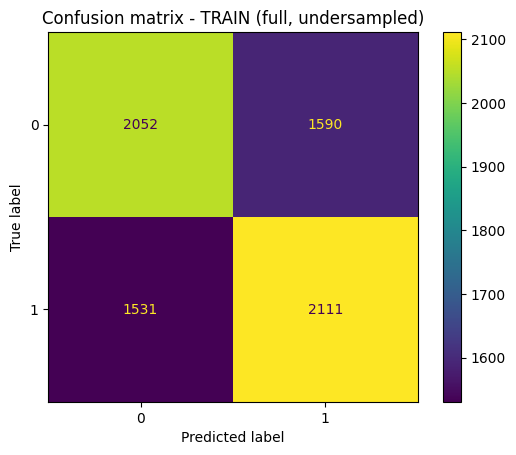

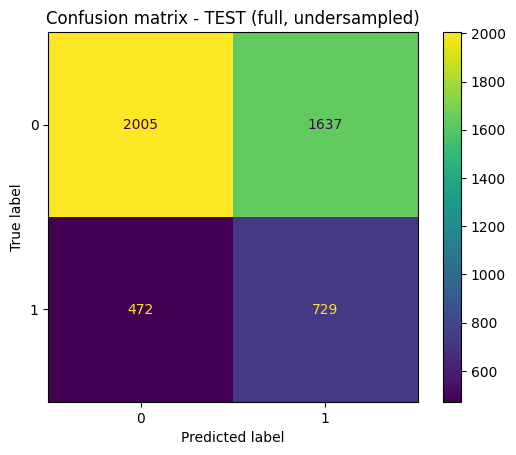



TRAIN classification report:
              precision    recall  f1-score   support

           0       0.57      0.56      0.57      3642
           1       0.57      0.58      0.57      3642

    accuracy                           0.57      7284
   macro avg       0.57      0.57      0.57      7284
weighted avg       0.57      0.57      0.57      7284

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.66      3642
           1       0.31      0.61      0.41      1201

    accuracy                           0.56      4843
   macro avg       0.56      0.58      0.53      4843
weighted avg       0.69      0.56      0.59      4843



In [11]:
# Logistic Regression with numerical and categorical numerical features. With balanced data.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

# X and y with ALL variables (numeric + dummies)
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Train/test split (test stays imbalanced)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Put train into a DataFrame for resampling
train_full_df = pd.concat([Xf_train, yf_train], axis=1)

# Split majority / minority
train_non_donors = train_full_df[train_full_df['TARGET_B'] == 0]
train_donors = train_full_df[train_full_df['TARGET_B'] == 1]

# Undersample majority to size of minority
train_non_donors_down = resample(
    train_non_donors,
    replace=False,
    n_samples=len(train_donors),
    random_state=42
)

# Balanced train set
train_full_bal = pd.concat([train_non_donors_down, train_donors])

Xf_train_bal = train_full_bal.drop('TARGET_B', axis=1)
yf_train_bal = train_full_bal['TARGET_B']

# Fit logistic regression on balanced full-features train
logreg_full_bal = LogisticRegression(solver='liblinear', max_iter=1000)
logreg_full_bal.fit(Xf_train_bal, yf_train_bal)

print("Balanced TRAIN accuracy =", logreg_full_bal.score(Xf_train_bal, yf_train_bal))
print("Original TEST accuracy  =", logreg_full_bal.score(Xf_test, yf_test))

print()

### Confusion matrices.

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
yf_train_bal_pred = logreg_full_bal.predict(Xf_train_bal)
yf_test_bal_pred  = logreg_full_bal.predict(Xf_test)

# TRAIN (balanced)
cm_train_full_bal = confusion_matrix(yf_train_bal, yf_train_bal_pred)
disp_train_full_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_train_full_bal,
    display_labels=logreg_full_bal.classes_
)
disp_train_full_bal.plot()
plt.title("Confusion matrix - TRAIN (full, undersampled)")
plt.show()

# TEST (original)
cm_test_full_bal = confusion_matrix(yf_test, yf_test_bal_pred)
disp_test_full_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_full_bal,
    display_labels=logreg_full_bal.classes_
)
disp_test_full_bal.plot()
plt.title("Confusion matrix - TEST (full, undersampled)")
plt.show()

print()

### Evaluation metrics
from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(yf_train_bal, yf_train_bal_pred, pos_label=1)
f1_test  = f1_score(yf_test, yf_test_bal_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(yf_train_bal, yf_train_bal_pred))

print("TEST classification report:")
print(classification_report(yf_test, yf_test_bal_pred))


Balanced TRAIN accuracy = 0.5715266337177375
Original TEST accuracy  = 0.5645261201734462



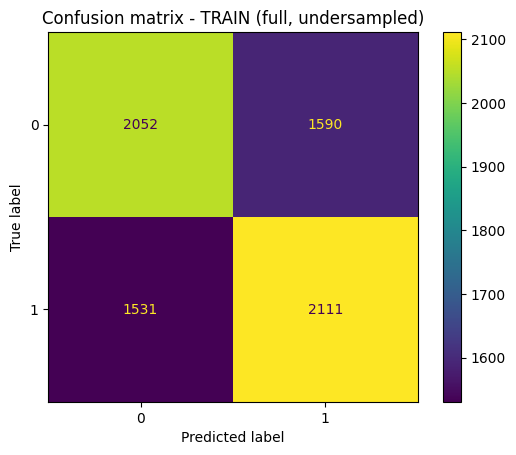

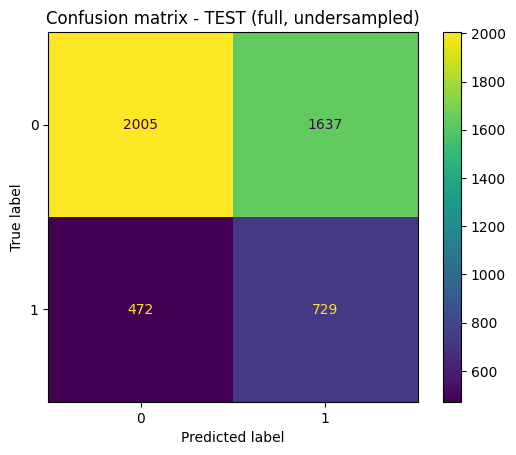



TRAIN classification report:
              precision    recall  f1-score   support

           0       0.57      0.56      0.57      3642
           1       0.57      0.58      0.57      3642

    accuracy                           0.57      7284
   macro avg       0.57      0.57      0.57      7284
weighted avg       0.57      0.57      0.57      7284

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.55      0.66      3642
           1       0.31      0.61      0.41      1201

    accuracy                           0.56      4843
   macro avg       0.56      0.58      0.53      4843
weighted avg       0.69      0.56      0.59      4843



In [12]:
### Logistic Regression with numerical and categorical numerical features. With balanced data. Adapted to do experiments with the c value, penalty and solver.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample

C = 1
penalty = 'l2' # or l1
solver = 'liblinear'

# Default parameters are:
# C = 1
# penalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

# X and y with ALL variables (numeric + dummies)
X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

# Train/test split (test stays imbalanced)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Put train into a DataFrame for resampling
train_full_df = pd.concat([Xf_train, yf_train], axis=1)

# Split majority / minority
train_non_donors = train_full_df[train_full_df['TARGET_B'] == 0]
train_donors = train_full_df[train_full_df['TARGET_B'] == 1]

# Undersample majority to size of minority
train_non_donors_down = resample(
    train_non_donors,
    replace=False,
    n_samples=len(train_donors),
    random_state=42
)

# Balanced train set
train_full_bal = pd.concat([train_non_donors_down, train_donors])

Xf_train_bal = train_full_bal.drop('TARGET_B', axis=1)
yf_train_bal = train_full_bal['TARGET_B']

# Fit logistic regression on balanced full-features train
logreg_full_bal = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=100000000)
logreg_full_bal.fit(Xf_train_bal, yf_train_bal)

print("Balanced TRAIN accuracy =", logreg_full_bal.score(Xf_train_bal, yf_train_bal))
print("Original TEST accuracy  =", logreg_full_bal.score(Xf_test, yf_test))

print()


### Confusion matrices.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
yf_train_bal_pred = logreg_full_bal.predict(Xf_train_bal)
yf_test_bal_pred  = logreg_full_bal.predict(Xf_test)

# TRAIN (balanced)
cm_train_full_bal = confusion_matrix(yf_train_bal, yf_train_bal_pred)
disp_train_full_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_train_full_bal,
    display_labels=logreg_full_bal.classes_
)
disp_train_full_bal.plot()
plt.title("Confusion matrix - TRAIN (full, undersampled)")
plt.show()

# TEST (original)
cm_test_full_bal = confusion_matrix(yf_test, yf_test_bal_pred)
disp_test_full_bal = ConfusionMatrixDisplay(
    confusion_matrix=cm_test_full_bal,
    display_labels=logreg_full_bal.classes_
)
disp_test_full_bal.plot()
plt.title("Confusion matrix - TEST (full, undersampled)")
plt.show()

print()

### Evaluation metrics
from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(yf_train_bal, yf_train_bal_pred, pos_label=1)
f1_test  = f1_score(yf_test, yf_test_bal_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(yf_train_bal, yf_train_bal_pred))

print("TEST classification report:")
print(classification_report(yf_test, yf_test_bal_pred))

TARGET_B                    0
RECENT_AVG_GIFT_AMT         0
LAST_GIFT_AMT               0
LIFETIME_AVG_GIFT_AMT       0
RECENT_AVG_CARD_GIFT_AMT    0
LIFETIME_MAX_GIFT_AMT       0
NUMBER_PROM_12              0
MONTHS_SINCE_LAST_GIFT      0
MONTHS_SINCE_FIRST_GIFT     0
LIFETIME_GIFT_COUNT         0
PER_CAPITA_INCOME           0
MEDIAN_HOUSEHOLD_INCOME     0
RECENT_RESPONSE_PROP        0
RECENT_RESPONSE_COUNT       0
URBANICITY                  0
SES                         0
DONOR_GENDER                0
RECENCY_STATUS_96NK         0
dtype: int64
Train set score (Accuracy) = 0.5834537820909904
Test set score (Accuracy)  = 0.5808383233532934



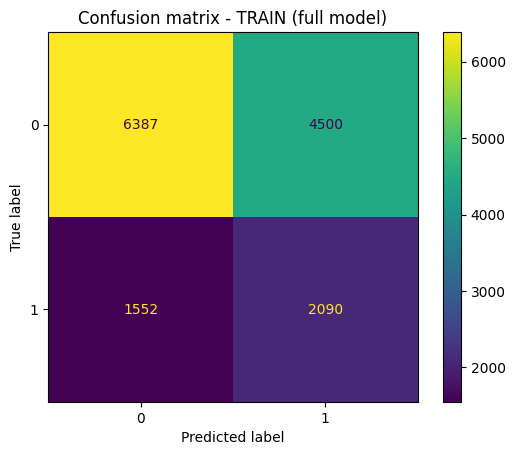

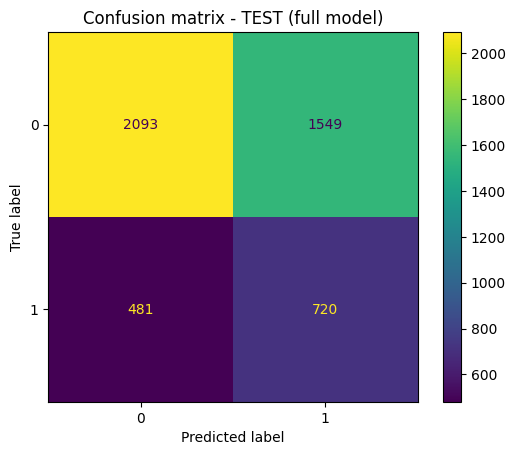


TRAIN classification report:
              precision    recall  f1-score   support

           0       0.80      0.59      0.68     10887
           1       0.32      0.57      0.41      3642

    accuracy                           0.58     14529
   macro avg       0.56      0.58      0.54     14529
weighted avg       0.68      0.58      0.61     14529

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.57      0.67      3642
           1       0.32      0.60      0.41      1201

    accuracy                           0.58      4843
   macro avg       0.57      0.59      0.54      4843
weighted avg       0.69      0.58      0.61      4843



In [36]:
### Logistic Regression with numerical and categorical numerical features. Adapted experiments with the c value, penalty and solver.
# Here, instead of doing undersampling, I used the automatic balancing of the logaritmic regression.

df_donors = pd.read_csv('Donors_dataset.csv')

df_donors


C = 100
penalty = 'l2' # or l1
solver = 'liblinear'

label_balance = 'balanced'

num_features = [
    "RECENT_AVG_GIFT_AMT", "LAST_GIFT_AMT", "LIFETIME_AVG_GIFT_AMT",
    "RECENT_AVG_CARD_GIFT_AMT", "LIFETIME_MAX_GIFT_AMT", "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT", "MONTHS_SINCE_FIRST_GIFT", "LIFETIME_GIFT_COUNT",
    "PER_CAPITA_INCOME", "MEDIAN_HOUSEHOLD_INCOME",
    "RECENT_RESPONSE_PROP", "RECENT_RESPONSE_COUNT"
]


#"WEALTH_RATING"


cat_features = [
    "URBANICITY", "SES", "DONOR_GENDER", "RECENCY_STATUS_96NK"

]

# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()




from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


# Default parameters are:
# C = 1
# pnalty = l2
# solver = 'liblinear'

# set c value. It controls regularization strength.
# High c = weak regularization (weights can be larger, more flexible model, more risk of overfitting)
# Low c = strong regularization (weights forced smaller, simpler model, more risk of underfitting).
# Default is 1.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_B_full = df_B_encoded.drop('TARGET_B', axis=1)
y_B_full = df_B_encoded['TARGET_B']

X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B_full, y_B_full, random_state=42
)

# Fit logistic regression
logreg_full = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=100000000, class_weight=label_balance)
logreg_full.fit(X_B_train, y_B_train)

# Accuracy
print("Train set score (Accuracy) =", logreg_full.score(X_B_train, y_B_train))
print("Test set score (Accuracy)  =", logreg_full.score(X_B_test, y_B_test))

print()


### Confusion matrices. Again the results are very bad. The problem might be related to data unbalance: almost 75% are non donors.

# Predictions
y_B_train_pred = logreg_full.predict(X_B_train)
y_B_test_pred  = logreg_full.predict(X_B_test)

# TRAIN confusion matrix
cm_train_full = confusion_matrix(y_B_train, y_B_train_pred)
disp_train_full = ConfusionMatrixDisplay(confusion_matrix=cm_train_full,
                                         display_labels=logreg_full.classes_)
disp_train_full.plot()
plt.title("Confusion matrix - TRAIN (full model)")
plt.show()

# TEST confusion matrix
cm_test_full = confusion_matrix(y_B_test, y_B_test_pred)
disp_test_full = ConfusionMatrixDisplay(confusion_matrix=cm_test_full,
                                        display_labels=logreg_full.classes_)
disp_test_full.plot()
plt.title("Confusion matrix - TEST (full model)")
plt.show()


### Evaluation metrics

from sklearn.metrics import f1_score, classification_report

# F1 for class 1 (donors)
f1_train = f1_score(y_B_train, y_B_train_pred, pos_label=1)
f1_test  = f1_score(y_B_test, y_B_test_pred, pos_label=1)

print("\nTRAIN classification report:")
print(classification_report(y_B_train, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))
